# Test ispezione, raffinamento e marcatura

Workflow:
1. import del modulo;
2. inizializzazione ZED/robot;
3. ispezione globale;
4. raffinamento;
5. marcatura controllata;

## 1 — Import del modulo

Questa cella importa `inspection_and_marking.py`.

`importlib.reload(im)` serve per ricaricare il file `.py` se lo modifichi in VSCode durante la sessione notebook.

**Nota:** dopo `reload`, i parametri tornano ai valori scritti nel file `.py`, quindi la cella successiva li risetta per il tuning.

In [1]:
import importlib
import numpy as np
import time
import matplotlib.pyplot as plt

import inspection_and_marking as im
import Variables as vb

im = importlib.reload(im)

print("Modulo inspection_and_marking importato e ricaricato.")

Modulo inspection_and_marking importato e ricaricato.


## 2 — Inizializzazione robot + ZED

**Attenzione: muove il robot** verso la posizione iniziale.

In [2]:
# Se non hai già inizializzato la ZED nella cella precedente, lascia questa parte attiva.
if "zed" not in globals():
    zed, runtime, image_zed, point_cloud = im.init_zed()
    print("ZED inizializzata.")
else:
    print("ZED già inizializzata.")

ZED inizializzata.


In [3]:
controller = im.RobotController(
    ip_address=im.IP_ROBOT,
    default_position_j=vb.LOOK_DOWN_POSITION_J_INIZIO
)

controller.connect()
print("Robot connesso.")

[15:46:42] INFO     Succesfully connected to robot Ethernet Slave and Modbus.                         techman.py:25

           INFO     Connected to Listen Node                                                          techman.py:37

Robot connesso.


In [4]:
# posizionamento iniziale
controller.default_positioning()
print("Robot in posizione iniziale.")

im.move_to_hub(controller)

Robot in posizione iniziale.
Ritorno alla posizione di hub [0, 0, 90].
  [CIRCLE] Movimento sferico: (1.9°, 124.6°) -> (0.0°, 90.0°)


In [5]:
# Switch per attivare/disattivare l'identificazione dei difetti generici
im.GENERIC_DETECTION = True

print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")

if im.GENERIC_DETECTION:
    print("Rilevamento generico dei difetti attivo.\n Attivazione dell'attention radius")
    im.GLOBAL_ATTENTION_RADIUS = 400 # Tuning: con detection generica serve un po' di attenzione per evitare falsi positivi ai bordi.
else:
    print("Rilevamento generico dei difetti disattivato.")
    im.GLOBAL_ATTENTION_RADIUS = None

Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius
Rilevamento generico dei difetti attivo.
 Attivazione dell'attention radius


## 3 — Ispezione globale completa

**Attenzione: muove il robot.**

=== ISPEZIONE GLOBALE ===
Numero posizioni di ispezione: 5
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).

------------------------------------------------------------
Scatto 1/5
Posizione sferica: [300, 0, 90]
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti trovati in questo scatto: 1
      Scatto 1 - difetto 1 rilevato:
        centroid: [551 365]
        pos3d_camera: [-13.8   0.7 148.7]
        Z camera: 148.7 mm
        radial camera: 13.9 mm
        pos3d_global: [-15.  661.  392.4]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]


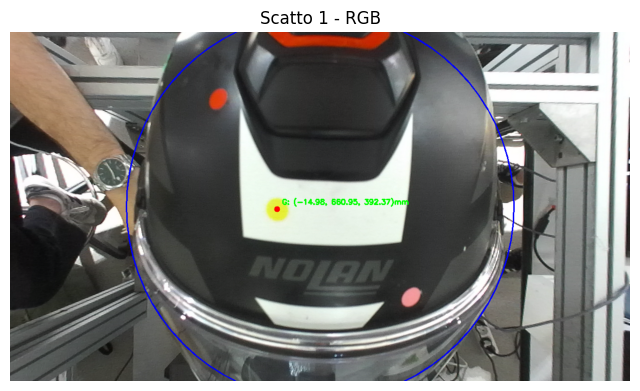

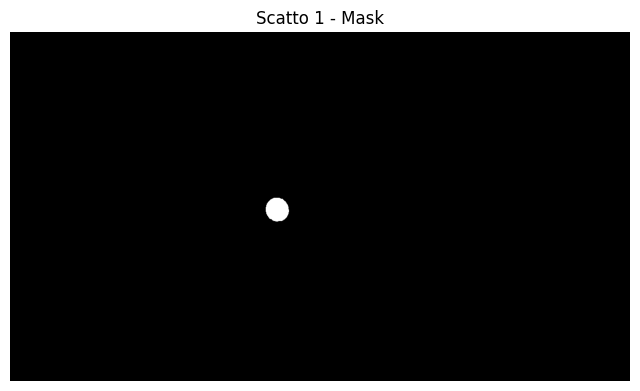


------------------------------------------------------------
Scatto 2/5
Posizione sferica: [300, 0, 45]
  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (0.0°, 45.0°)
Difetti trovati in questo scatto: 1
      Scatto 2 - difetto 1 rilevato:
        centroid: [262 378]
        pos3d_camera: [-80.8   1.1 168.3]
        Z camera: 168.3 mm
        radial camera: 80.8 mm
        pos3d_global: [-81.9 754.  335. ]
        sph_coord [r, alpha, beta]: [154.5 -40.7  53.3]


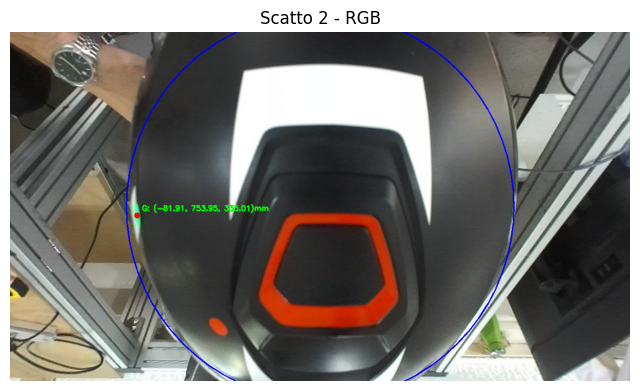

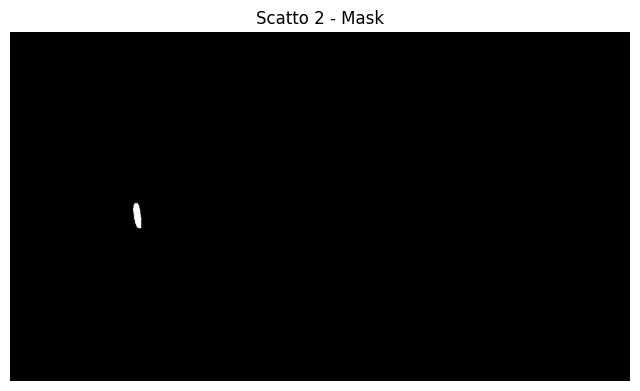


------------------------------------------------------------
Scatto 3/5
Posizione sferica: [300, 0, 30]
  [CIRCLE] Movimento sferico: (-0.0°, 45.0°) -> (0.0°, 30.0°)
Difetti trovati in questo scatto: 1
      Scatto 3 - difetto 1 rilevato:
        centroid: [737  12]
        pos3d_camera: [ 20.7 -61.2 128.1]
        Z camera: 128.1 mm
        radial camera: 64.6 mm
        pos3d_global: [ 19.5 841.2 274.1]
        sph_coord [r, alpha, beta]: [183.7  32.1  12.2]


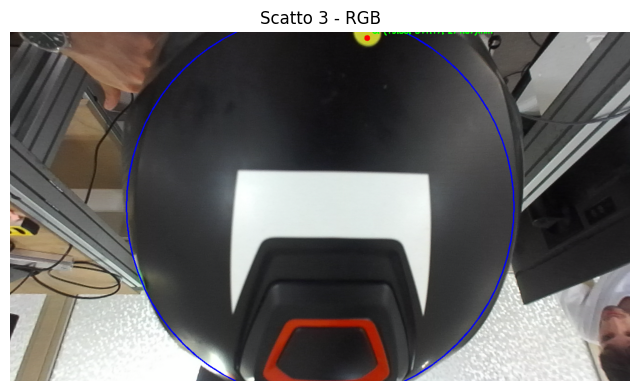

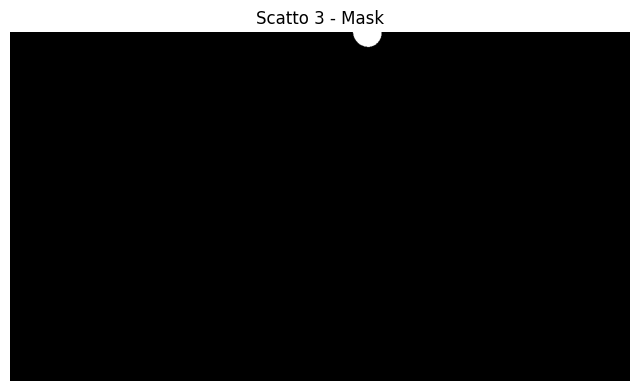


------------------------------------------------------------
Scatto 4/5
Posizione sferica: [300, 87, 60]
  [CIRCLE] Movimento sferico: (-0.0°, 30.0°) -> (87.0°, 60.0°)
Difetti trovati in questo scatto: 2
      Scatto 4 - difetto 1 rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.3 144.2]
        Z camera: 144.2 mm
        radial camera: 47.0 mm
        pos3d_global: [116.6 765.8 283.1]
        sph_coord [r, alpha, beta]: [162.8  70.4  50.2]
      Scatto 4 - difetto 2 rilevato:
        centroid: [860  77]
        pos3d_camera: [ 49.  -58.  149.2]
        Z camera: 149.2 mm
        radial camera: 76.0 mm
        pos3d_global: [102.8 787.3 197.4]
        sph_coord [r, alpha, beta]: [168.8 112.8  41.9]


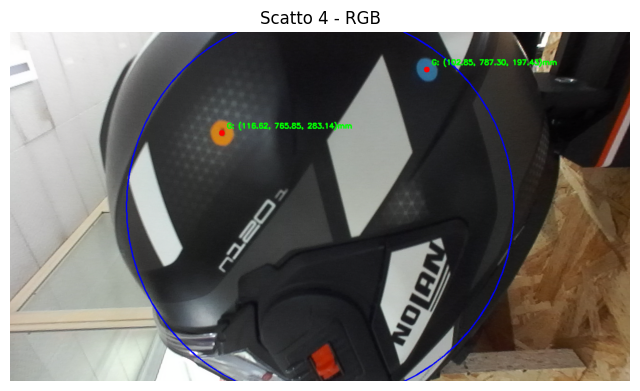

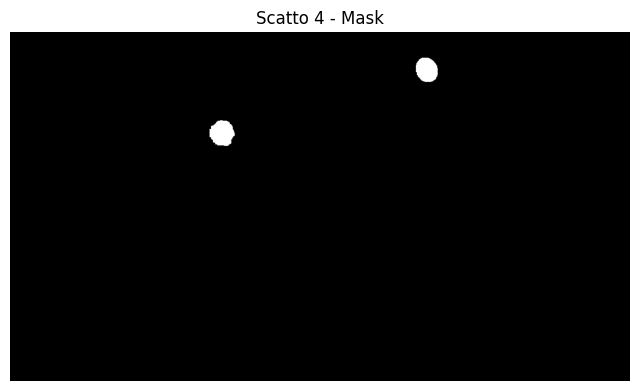


------------------------------------------------------------
Scatto 5/5
Posizione sferica: [300, -87, 60]
  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (87.0°, 60.0°) -> (0.0°, 60.0°)
  [CIRCLE] Movimento sferico: (0.0°, 60.0°) -> (-87.0°, 60.0°)
Difetti trovati in questo scatto: 3
      Scatto 5 - difetto 1 rilevato:
        centroid: [991 243]
        pos3d_camera: [ 86.9 -27.9 171. ]
        Z camera: 171.0 mm
        radial camera: 91.3 mm
        pos3d_global: [-94.3 750.3 333. ]
        sph_coord [r, alpha, beta]: [158.1 -45.4  55.9]
      Scatto 5 - difetto 2 rilevato:
        centroid: [729 216]
        pos3d_camera: [ 22.6 -29.8 150. ]
        Z camera: 150.0 mm
        radial camera: 37.4 mm
        pos3d_global: [-114.8  762.5  269.7]
        sph_coord [r, alpha, beta]: [154.6 -75.9  49.3]
      Scatto 5 - difetto 3 rilevato:
        centroid: [452 133]
        pos3d_camera: [-35.4 -48.5 155.4]
        Z camera: 155.4 mm
  

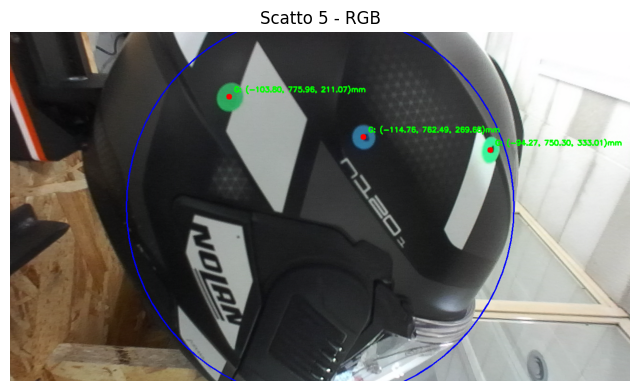

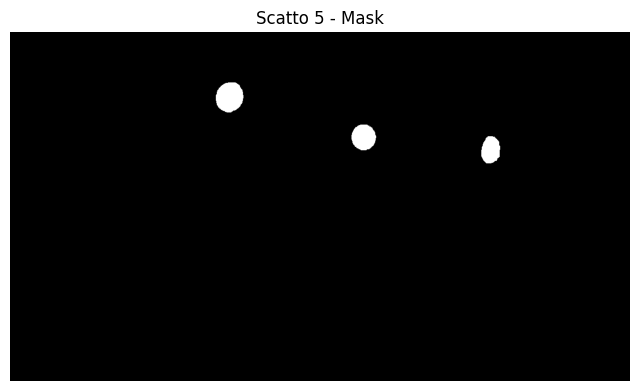


=== ISPEZIONE COMPLETATA ===
Difetti totali prima del filtro duplicati: 8
Difetti univoci dopo filtro duplicati: 7
      Difetto unico 1 rilevato:
        centroid: [551 365]
        pos3d_camera: [-13.8   0.7 148.7]
        Z camera: 148.7 mm
        radial camera: 13.9 mm
        pos3d_global: [-15.  661.  392.4]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]
      Difetto unico 2 rilevato:
        centroid: [262 378]
        pos3d_camera: [-80.8   1.1 168.3]
        Z camera: 168.3 mm
        radial camera: 80.8 mm
        pos3d_global: [-81.9 754.  335. ]
        sph_coord [r, alpha, beta]: [154.5 -40.7  53.3]
      Difetto unico 3 rilevato:
        centroid: [737  12]
        pos3d_camera: [ 20.7 -61.2 128.1]
        Z camera: 128.1 mm
        radial camera: 64.6 mm
        pos3d_global: [ 19.5 841.2 274.1]
        sph_coord [r, alpha, beta]: [183.7  32.1  12.2]
      Difetto unico 4 rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.3 144.2]
        

In [6]:
all_defects = []

INSPECTION_POSITIONS = [
    [im.INSPECTION_RADIUS,   0, 90],   # alto
    [im.INSPECTION_RADIUS,   0, 45],   # frontale/intermedio
    [im.INSPECTION_RADIUS,   0, 30],   # frontale/intermedio
    [im.INSPECTION_RADIUS,  87, 60],   # laterale destro
    [im.INSPECTION_RADIUS, -87, 60],   # laterale sinistro
]

# commenta se vuoi usare delle posizoni personalizzate, altrimenti usa quelle di default
# INSPECTION_POSITIONS = im.INSPECTION_POSITIONS

print("=== ISPEZIONE GLOBALE ===")
print(f"Numero posizioni di ispezione: {len(INSPECTION_POSITIONS)}")

im.move_to_hub(controller)

for i, inspection_position in enumerate(INSPECTION_POSITIONS):

    if input(f"\nPremi Invio per eseguire lo scatto in posizione {inspection_position}") != "":
        print("Scatto saltato.")
        continue

    print("\n" + "-" * 60)
    print(f"Scatto {i + 1}/{len(INSPECTION_POSITIONS)}")
    print(f"Posizione sferica: {inspection_position}")

    defect_list, debug_img, mask_bgr, bgr_image = im.point_and_shoot(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        test_sph=inspection_position,
        insp_radius=im.INSPECTION_RADIUS,           # è già così di default ma non si sa mai
        helmet_center=vb.HELMET_CENTER_GLOBAL
    )

    print(f"Difetti trovati in questo scatto: {len(defect_list)}")

    for idx, d in enumerate(defect_list):
        d.say_hi(Name=f"Scatto {i + 1} - difetto {idx + 1}")

    all_defects.extend(defect_list)

    im.show_debug_matplotlib(
        debug_img=debug_img,
        mask_bgr=mask_bgr,
        title=f"Scatto {i + 1}"
    )

print("\n=== ISPEZIONE COMPLETATA ===")
print(f"Difetti totali prima del filtro duplicati: {len(all_defects)}")

unique_defects = im.duplicate_filter(
    all_defects,
    distance_threshold=im.DUPLICATE_DISTANCE
)

print(f"Difetti univoci dopo filtro duplicati: {len(unique_defects)}")


for idx, d in enumerate(unique_defects):
    d.say_hi(Name=f"Difetto unico {idx + 1}")

print("\nRitorno all'hub...")
im.move_to_hub(controller)

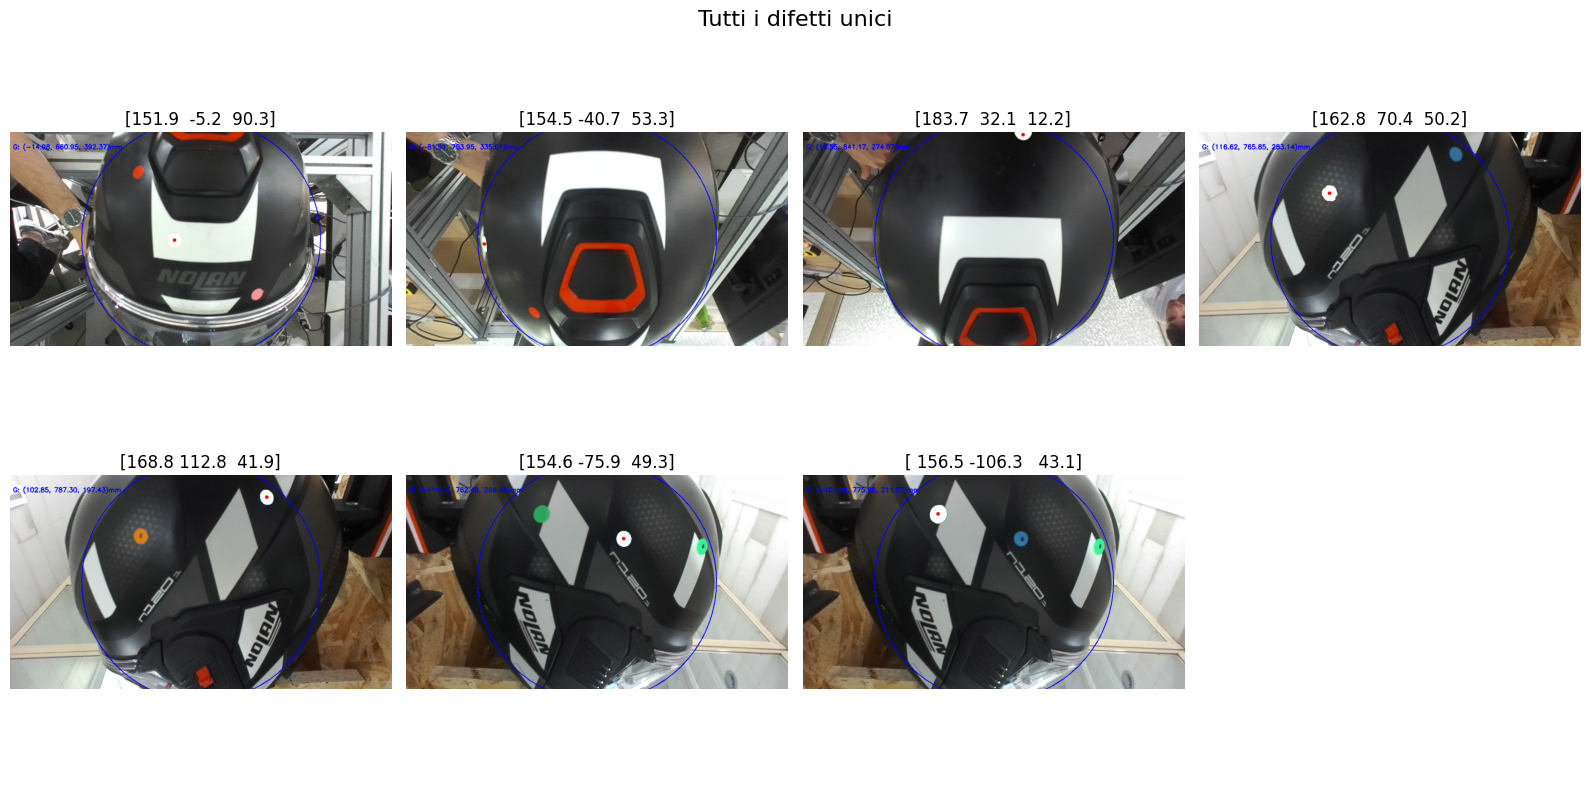

In [7]:
if len(unique_defects) == 0:
    print("Nessun difetto univoco da visualizzare.")
else:
    n_defects = len(unique_defects)
    cols = min(4, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, unique_defects):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle("Tutti i difetti unici", fontsize=16)
    plt.tight_layout()
    plt.show()

## 4 — Raffinamento di ogni difetto

**Attenzione: muove il robot.**

=== RAFFINAMENTO DI TUTTI I DIFETTI ===
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti da raffinare: 7

------------------------------------------------------------
Raffinamento difetto 1/7
      Difetto 1 prima del raffinamento rilevato:
        centroid: [551 365]
        pos3d_camera: [-13.8   0.7 148.7]
        Z camera: 148.7 mm
        radial camera: 13.9 mm
        pos3d_global: [-15.  661.  392.4]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]


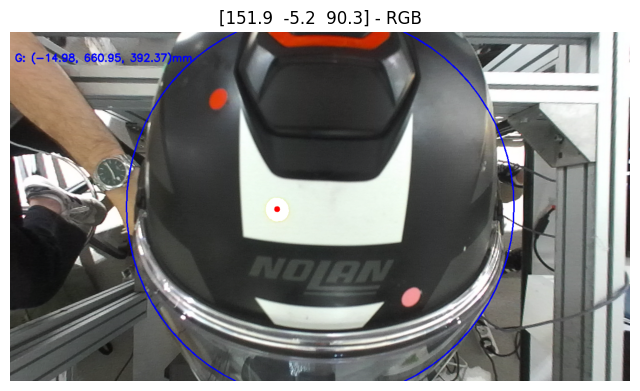

 Raffinamento difetto: r_stimato=151.9mm, alpha=-5.2°, beta=90.3°
  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (-5.2°, 90.3°)
  Movimento camera a r=300mm nella direzione del difetto.
    Scatto 1/10: rilevati 1 difetti.
    Scatto 1/10: trovato, distanza=0.9mm
      Best Match #1 rilevato:
        centroid: [614 362]
        pos3d_camera: [-9.000e-01  1.000e-01  1.481e+02]
        Z camera: 148.1 mm
        radial camera: 0.9 mm
        pos3d_global: [-15.9 660.9 392.3]
        sph_coord [r, alpha, beta]: [151.9  -5.6  90.3]
    Scatto 2/10: rilevati 1 difetti.
    Scatto 2/10: trovato, distanza=1.0mm
      Best Match #2 rilevato:
        centroid: [614 362]
        pos3d_camera: [-9.00e-01  1.00e-01  1.48e+02]
        Z camera: 148.0 mm
        radial camera: 0.9 mm
        pos3d_global: [-15.9 660.8 392.3]
        sph_coord [r, alpha, beta]: [152.   -5.6  90.3]
    Scatto 3/10: rilevati 1 difetti.
    Scatto 3/10: trovato, distanza=0.9mm
      Best Match #3 rilevato:
        cent

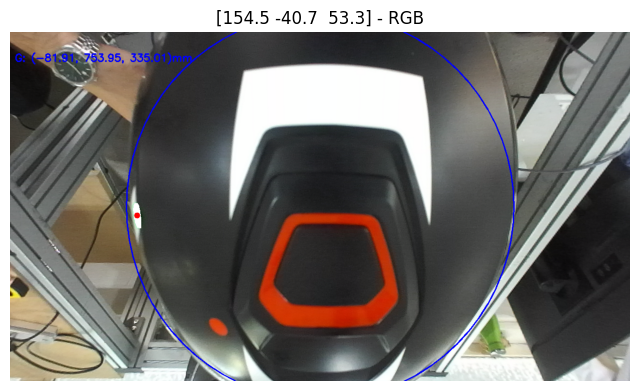

 Raffinamento difetto: r_stimato=154.5mm, alpha=-40.7°, beta=53.3°
  [CIRCLE] Movimento sferico: (-5.2°, 90.3°) -> (-40.7°, 53.3°)
  Movimento camera a r=300mm nella direzione del difetto.
    Scatto 1/10: rilevati 1 difetti.
    Scatto 1/10: trovato, distanza=7.9mm
      Best Match #1 rilevato:
        centroid: [599 394]
        pos3d_camera: [ -3.8   6.1 142.4]
        Z camera: 142.4 mm
        radial camera: 7.2 mm
        pos3d_global: [-88.8 750.9 337.2]
        sph_coord [r, alpha, beta]: [157.8 -42.4  55.6]
    Scatto 2/10: rilevati 1 difetti.
    Scatto 2/10: trovato, distanza=7.9mm
      Best Match #2 rilevato:
        centroid: [600 393]
        pos3d_camera: [ -3.8   6.1 142.4]
        Z camera: 142.4 mm
        radial camera: 7.2 mm
        pos3d_global: [-88.8 750.9 337.2]
        sph_coord [r, alpha, beta]: [157.7 -42.4  55.5]
    Scatto 3/10: rilevati 1 difetti.
    Scatto 3/10: trovato, distanza=7.9mm
      Best Match #3 rilevato:
        centroid: [599 393]
        p

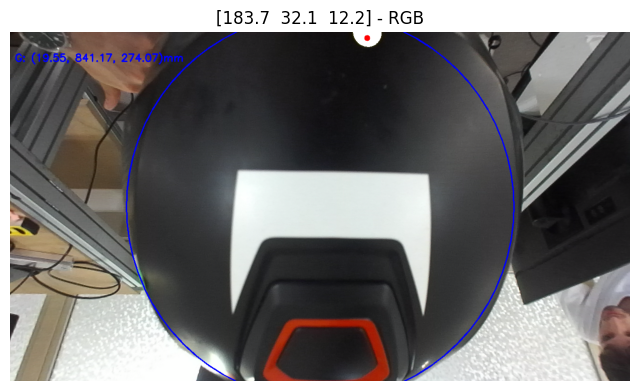

 Raffinamento difetto: r_stimato=183.7mm, alpha=32.1°, beta=12.2°
  [SKIP] Destinazione (alpha=32.1°, beta=12.2°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 3 scartato/non confermato/irraggiungibile.

------------------------------------------------------------
Raffinamento difetto 4/7
      Difetto 4 prima del raffinamento rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.3 144.2]
        Z camera: 144.2 mm
        radial camera: 47.0 mm
        pos3d_global: [116.6 765.8 283.1]
        sph_coord [r, alpha, beta]: [162.8  70.4  50.2]


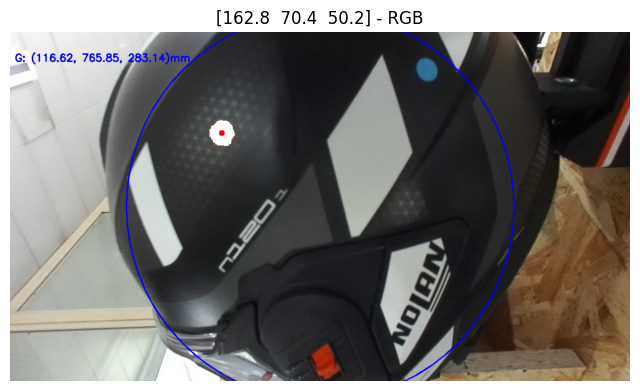

 Raffinamento difetto: r_stimato=162.8mm, alpha=70.4°, beta=50.2°
  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (-40.7°, 53.3°) -> (14.8°, 51.8°)
  [CIRCLE] Movimento sferico: (14.8°, 51.8°) -> (70.4°, 50.2°)
  Movimento camera a r=300mm nella direzione del difetto.
    Scatto 1/10: rilevati 1 difetti.
    Scatto 1/10: trovato, distanza=4.3mm
      Best Match #1 rilevato:
        centroid: [601 355]
        pos3d_camera: [ -3.3  -1.3 139.6]
        Z camera: 139.6 mm
        radial camera: 3.6 mm
        pos3d_global: [113.  765.3 285.4]
        sph_coord [r, alpha, beta]: [160.4  68.8  49.8]
    Scatto 2/10: rilevati 1 difetti.
    Scatto 2/10: trovato, distanza=3.5mm
      Best Match #2 rilevato:
        centroid: [601 356]
        pos3d_camera: [ -3.3  -1.2 136.9]
        Z camera: 136.9 mm
        radial camera: 3.5 mm
        pos3d_global: [115.  767.  286.1]
        sph_coord [r, alpha, beta]: [163.1  68.8  49.8]
    Scatto 3/10:

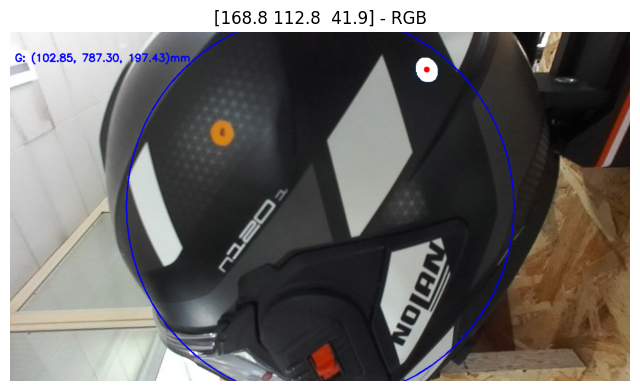

 Raffinamento difetto: r_stimato=168.8mm, alpha=112.8°, beta=41.9°
  [SKIP] Destinazione (alpha=112.8°, beta=41.9°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 5 scartato/non confermato/irraggiungibile.

------------------------------------------------------------
Raffinamento difetto 6/7
      Difetto 6 prima del raffinamento rilevato:
        centroid: [729 216]
        pos3d_camera: [ 22.6 -29.8 150. ]
        Z camera: 150.0 mm
        radial camera: 37.4 mm
        pos3d_global: [-114.8  762.5  269.7]
        sph_coord [r, alpha, beta]: [154.6 -75.9  49.3]


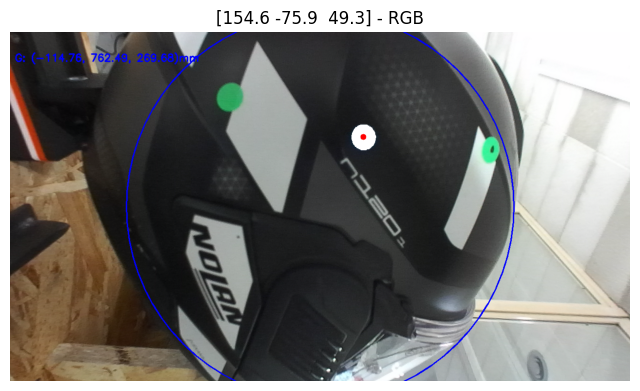

 Raffinamento difetto: r_stimato=154.6mm, alpha=-75.9°, beta=49.3°
  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (70.4°, 50.2°) -> (-2.8°, 49.7°)
  [CIRCLE] Movimento sferico: (-2.8°, 49.7°) -> (-75.9°, 49.3°)
  Movimento camera a r=300mm nella direzione del difetto.
    Scatto 1/10: rilevati 1 difetti.
    Scatto 1/10: trovato, distanza=2.6mm
      Best Match #1 rilevato:
        centroid: [625 351]
        pos3d_camera: [  1.3  -2.2 145.7]
        Z camera: 145.7 mm
        radial camera: 2.6 mm
        pos3d_global: [-112.8  764.   270.5]
        sph_coord [r, alpha, beta]: [154.3 -75.2  48.5]
    Scatto 2/10: rilevati 1 difetti.
    Scatto 2/10: trovato, distanza=2.6mm
      Best Match #2 rilevato:
        centroid: [626 351]
        pos3d_camera: [  1.3  -2.2 145.7]
        Z camera: 145.7 mm
        radial camera: 2.6 mm
        pos3d_global: [-112.8  764.   270.5]
        sph_coord [r, alpha, beta]: [154.3 -75.2  48.5]
    Scatt

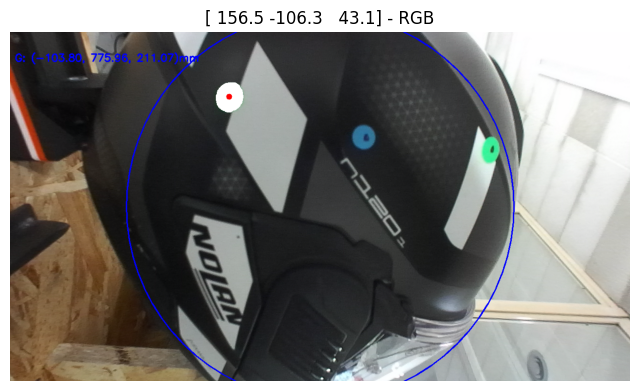

 Raffinamento difetto: r_stimato=156.5mm, alpha=-106.3°, beta=43.1°
  [SKIP] Destinazione (alpha=-106.3°, beta=43.1°) fuori limiti sicurezza.
  [SKIP] Impossibile raggiungere la posizione ravvicinata in sicurezza.
Difetto 7 scartato/non confermato/irraggiungibile.

=== RAFFINAMENTO COMPLETATO ===
Difetti iniziali: 7
Difetti raffinati/confermati: 4
      Difetto raffinato 1 rilevato:
        centroid: [551 365]
        pos3d_camera: [-13.8   0.7 148.7]
        Z camera: 148.7 mm
        radial camera: 13.9 mm
        pos3d_global: [-15.9 660.9 392.4]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]
      Difetto raffinato 2 rilevato:
        centroid: [262 378]
        pos3d_camera: [-80.8   1.1 168.3]
        Z camera: 168.3 mm
        radial camera: 80.8 mm
        pos3d_global: [-88.8 750.9 337.2]
        sph_coord [r, alpha, beta]: [154.5 -40.7  53.3]
      Difetto raffinato 3 rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.3 144.2]
        Z camera: 14

In [8]:
print("=== RAFFINAMENTO DI TUTTI I DIFETTI ===")
im.move_to_hub(controller)

refined_defects = []

print(f"Difetti da raffinare: {len(unique_defects)}")

for i, d in enumerate(unique_defects.copy()):  # Crea una copia per iterare

    print("\n" + "-" * 60)
    print(f"Raffinamento difetto {i + 1}/{len(unique_defects)}")

    d.say_hi(Name=f"Difetto {i + 1} prima del raffinamento")
    im.show_debug_matplotlib(d.img(), title=f"{np.round(d.sph_coord,1)}")

    if input(f"\nPremi Invio per il raffinamento in posizione {np.round(d.sph_coord, 2)}") != "":
        print("raffinamento saltato.")
        continue
    
    success = im.refine_defect_position(
        controller=controller,
        zed=zed,
        runtime=runtime,
        image_zed=image_zed,
        point_cloud=point_cloud,
        defect_obj=d,
        helmet_center=vb.HELMET_CENTER_GLOBAL,
        generic_detection=im.GENERIC_DETECTION
    )

    if success:
        print(f"Difetto {i + 1} raffinato correttamente.")
        d.say_hi(Name=f"Difetto {i + 1} raffinato")
        refined_defects.append(d)
    else:
        print(f"Difetto {i + 1} scartato/non confermato/irraggiungibile.")

print("\n=== RAFFINAMENTO COMPLETATO ===")
print(f"Difetti iniziali: {len(unique_defects)}")
print(f"Difetti raffinati/confermati: {len(refined_defects)}")

for i, d in enumerate(refined_defects):
    d.say_hi(Name=f"Difetto raffinato {i + 1}")

print("\nRitorno alla posizione iniziale...")
im.move_to_hub(controller)
print("Robot tornato in posizione iniziale.")

=== VISUALIZZA TUTTI I DIFETTI RAFFINATI ===


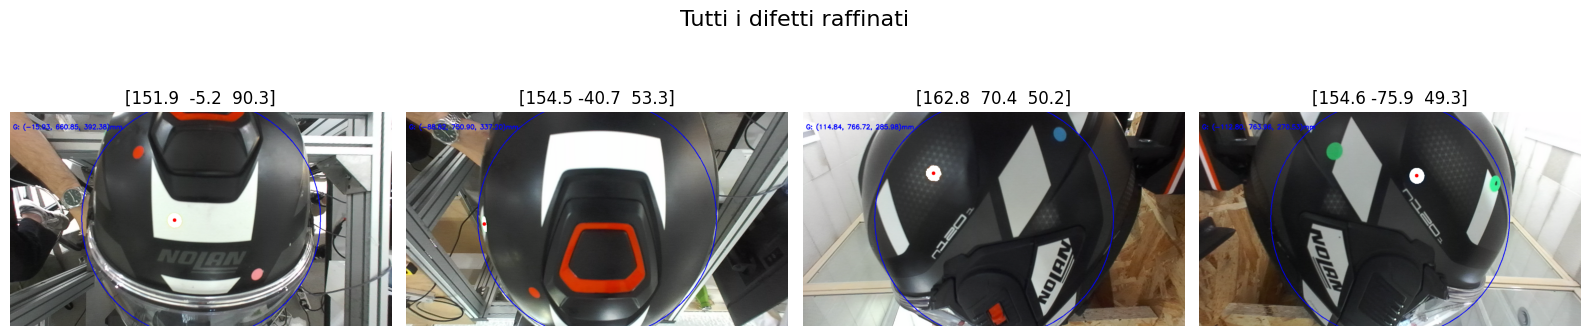

In [9]:
print("=== VISUALIZZA TUTTI I DIFETTI RAFFINATI ===")
if len(refined_defects) == 0:
    print("Nessun difetto raffinato da visualizzare.")
else:
    n_defects = len(refined_defects)
    cols = min(4, n_defects)
    rows = int(np.ceil(n_defects / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, d in zip(axes, refined_defects):
        img = d.img()
        if img is None:
            ax.axis("off")
            continue

        if img.ndim == 3 and img.shape[-1] == 3:
            img = img[..., ::-1]

        ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(f"{np.round(d.sph_coord,1)}")
        ax.axis("off")

    for ax in axes[n_defects:]:
        ax.axis("off")

    fig.suptitle("Tutti i difetti raffinati", fontsize=16)
    plt.tight_layout()
    plt.show()

## 5 — Marcatura di ogni difetto

**Attenzione: muove il robot e prova a marcare con il pennarello.**

=== MARCATURA DI TUTTI I DIFETTI VALIDI ===
Ritorno alla posizione di hub [0, 0, 90].
  [SHORT PATH] Distanza angolare < 5°. Esecuzione ottimizzata PTP verso (alpha=0.0°, beta=90.0°).
Difetti validi da marcare: 4

------------------------------------------------------------
Marcatura difetto 1/4
      Difetto 1 da marcare rilevato:
        centroid: [551 365]
        pos3d_camera: [-13.8   0.7 148.7]
        Z camera: 148.7 mm
        radial camera: 13.9 mm
        pos3d_global: [-15.9 660.9 392.4]
        sph_coord [r, alpha, beta]: [151.9  -5.2  90.3]


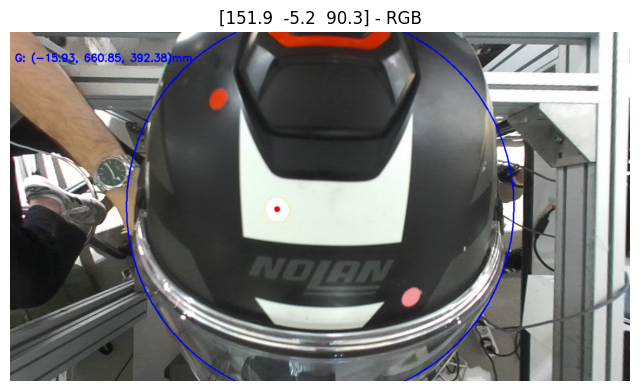

  [CIRCLE] Movimento sferico: (-0.0°, 90.0°) -> (-5.2°, 90.3°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [-15.9 660.9 392.4] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [-3.640e+01  6.599e+02  6.295e+02 -1.748e+02  3.000e-01 -9.000e+01]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 1 marcato correttamente.

------------------------------------------------------------
Marcatura difetto 2/4
      Difetto 2 da marcare rilevato:
        centroid: [262 378]
        pos3d_camera: [-80.8   1.1 168.3]
        Z camera: 168.3 mm
        radial camera: 80.8 mm
        pos3d_global: [-88.8 750.9 337.2]
        sph_coord [r, alpha, beta]: [154.5 -40.7  53.3]


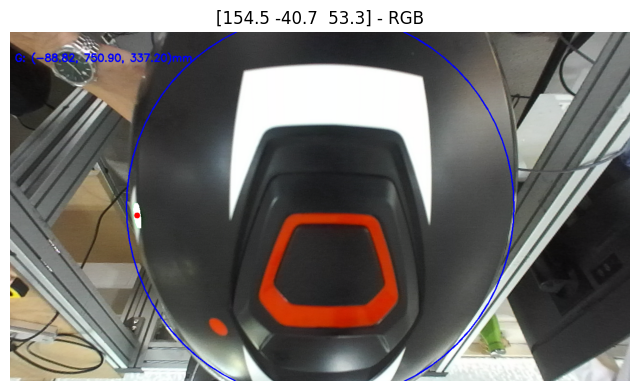

  [CIRCLE] Movimento sferico: (-5.2°, 90.3°) -> (-40.7°, 53.3°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [-88.8 750.9 337.2] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [-204.9  894.7  478.3 -133.   -26.9 -115.9]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 2 marcato correttamente.

------------------------------------------------------------
Marcatura difetto 3/4
      Difetto 3 da marcare rilevato:
        centroid: [437 208]
        pos3d_camera: [-35.8 -30.3 144.2]
        Z camera: 144.2 mm
        radial camera: 47.0 mm
        pos3d_global: [114.8 766.7 286. ]
        sph_coord [r, alpha, beta]: [162.8  70.4  50.2]


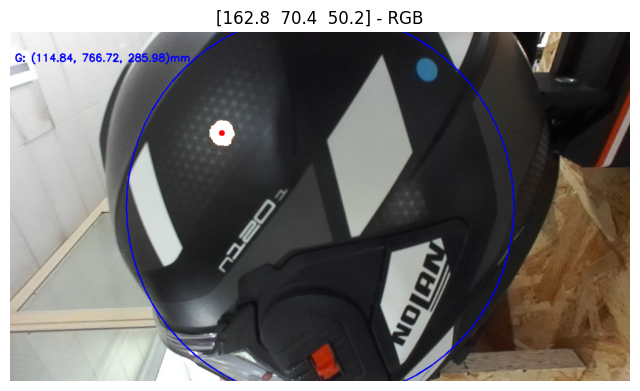

  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (-40.7°, 53.3°) -> (14.8°, 51.8°)
  [CIRCLE] Movimento sferico: (14.8°, 51.8°) -> (70.4°, 50.2°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [114.8 766.7 286. ] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [281.1 911.3 341.6 105.3 -12.4 -51.9]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 3 marcato correttamente.

------------------------------------------------------------
Marcatura difetto 4/4
      Difetto 4 da marcare rilevato:
        centroid: [729 216]
        pos3d_camera: [ 22.6 -29.8 150. ]
        Z camera: 150.0 mm
        radial camera: 37.4 mm
        pos3d_global: [-112.8  764.   270.5]
        sph_coord [r, alpha, beta]: [154.6 -75.9  49.3]


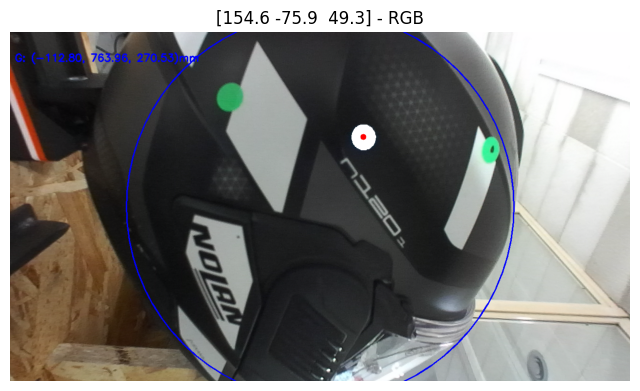

  [SPLIT] Traiettoria sferica ampia. Suddivisione in due segmenti.
  [CIRCLE] Movimento sferico: (70.3°, 50.2°) -> (-2.8°, 49.7°)
  [CIRCLE] Movimento sferico: (-2.8°, 49.7°) -> (-75.9°, 49.3°)
  Movimento camera a r=300mm nella direzione del difetto.
  Avvio marcatura difetto in [-112.8  764.   270.5] mm
    Punto di approccio a r=250.0mm.
    Posa approccio EE: [-287.7  916.1  313.4 -100.8   -9.2 -129.9]
    Avanzamento lineare al difetto.
    Arretramento lineare.
    Marcatura completata.
Difetto 4 marcato correttamente.

=== MARCATURA COMPLETATA ===
Difetti validi: 4
Difetti marcati: 4

Ritorno alla posizione iniziale...
Ritorno alla posizione di hub [0, 0, 90].
  [CIRCLE] Movimento sferico: (-75.9°, 49.3°) -> (0.0°, 90.0°)
Robot tornato in posizione iniziale.


In [10]:
print("=== MARCATURA DI TUTTI I DIFETTI VALIDI ===")
im.move_to_hub(controller)

# Usa refined_defects se hai fatto la cella di raffinamento.
# Se invece vuoi marcare direttamente quelli dell'ispezione globale, cambia in unique_defects.
valid_defects = refined_defects

print(f"Difetti validi da marcare: {len(valid_defects)}")


marked_defects = []

if not input(f"Premi INVIO per marcare tutti i difetti validi, scrivi nope per annullare: ") == "nope":

    for i, d in enumerate(valid_defects):

        print("\n" + "-" * 60)
        print(f"Marcatura difetto {i + 1}/{len(valid_defects)}")
        d.say_hi(Name=f"Difetto {i + 1} da marcare")
        im.show_debug_matplotlib(d.img(), title=f"{np.round(d.sph_coord,1)}")


        if input(f"\nPremi Invio per marcare il difetto in posizione {np.round(d.sph_coord, 2)}") != "":
            print("Marcatura saltata.")
            continue

        success = im.mark_defect(
            controller=controller,
            defect_obj=d,
            helmet_center=vb.HELMET_CENTER_GLOBAL
        )

        if success:
            print(f"Difetto {i + 1} marcato correttamente.")
            marked_defects.append(d)
        else:
            print(f"Difetto {i + 1} non marcato.")

else:
    print("Marcatura annullata.")

print("\n=== MARCATURA COMPLETATA ===")
print(f"Difetti validi: {len(valid_defects)}")
print(f"Difetti marcati: {len(marked_defects)}")

print("\nRitorno alla posizione iniziale...")
im.move_to_hub(controller)
controller.default_positioning()
print("Robot tornato in posizione iniziale.")

## 6 — RESOCONTO

In [ ]:
print("=== RESOCONTO FINALE ===")

counts = {
    "Difetti unici": len(unique_defects) if "unique_defects" in globals() else 0,
    "Difetti raffinati": len(refined_defects) if "refined_defects" in globals() else 0,
    "Difetti marcati": len(marked_defects) if "marked_defects" in globals() else 0,
}

print(f"Difetti unici: {counts['Difetti unici']}")
print(f"Difetti raffinati: {counts['Difetti raffinati']}")
print(f"Difetti marcati: {counts['Difetti marcati']}")


def collect_positions(defect_list):
    xs, ys = [], []
    for d in defect_list:
        pos = getattr(d, "pos3d_global", None)
        if pos is None:
            pos = getattr(d, "centroid", None)
        if pos is None:
            continue
        pos = np.array(pos)
        if pos.size >= 2:
            xs.append(pos[0])
            ys.append(pos[1])
    return xs, ys

positions = {
    "Unici": collect_positions(unique_defects) if "unique_defects" in globals() else ([], []),
    "Raffinati": collect_positions(refined_defects) if "refined_defects" in globals() else ([], []),
    "Marcati": collect_positions(marked_defects) if "marked_defects" in globals() else ([], []),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(counts.keys(), counts.values(), color=["#1f77b4", "#2ca02c", "#d62728"])
for label, value in counts.items():
    axes[0].text(label, value + 0.1, str(value), ha="center", va="bottom", fontsize=12)
axes[0].set_title("Conteggi dei difetti")
axes[0].set_ylabel("Numero di difetti")
axes[0].grid(axis="y", alpha=0.3)

markers = {"Unici": "o", "Raffinati": "s", "Marcati": "^"}
colors = {"Unici": "#1f77b4", "Raffinati": "#2ca02c", "Marcati": "#d62728"}
for label, (xs, ys) in positions.items():
    axes[1].scatter(
        xs,
        ys,
        label=f"{label} ({len(xs)})",
        marker=markers[label],
        color=colors[label],
        alpha=0.7,
        edgecolor="black" if len(xs) > 0 else "none",
        linewidth=0.5,
        s=60,
    )

axes[1].set_title("Distribuzione delle posizioni difetti")
axes[1].set_xlabel("X [mm]")
axes[1].set_ylabel("Y [mm]")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Resoconto finale: difetti unici, raffinati e marcati", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()